In [ ]:
!pip install torch torchvision torchaudio
!pip install datasets transformers

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from datasets import load_dataset
from transformers import AutoTokenizer
import random

In [ ]:
dataset = load_dataset("imdb")

tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

def tokenize(example):
    return tokenizer(example["text"], padding="max_length", truncation=True, max_length=128)

dataset = dataset.map(tokenize, batched=True)
dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])

train_loader = torch.utils.data.DataLoader(dataset["train"], batch_size=16, shuffle=True)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Map:   0%|          | 0/50000 [00:00<?, ? examples/s]

In [ ]:
class GRUExpert(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.gru = nn.GRU(embed_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, 2)

    def forward(self, x):
        x = self.embedding(x)
        _, h = self.gru(x)
        return self.fc(h[-1])

In [ ]:
class LSTMExpert(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, 2)

    def forward(self, x):
        x = self.embedding(x)
        _, (h, _) = self.lstm(x)
        return self.fc(h[-1])

In [ ]:
class TransformerExpert(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_heads):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        encoder_layer = nn.TransformerEncoderLayer(d_model=embed_dim, nhead=num_heads)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=2)
        self.fc = nn.Linear(embed_dim, 2)

    def forward(self, x):
        x = self.embedding(x)
        x = self.transformer(x)
        x = x.mean(dim=1)
        return self.fc(x)

In [ ]:
class Router:
    def __init__(self):
        self.usage = [0, 0, 0]  # GRU, LSTM, Transformer
        self.lambda_penalty = 0.05

    def compute_features(self, input_ids):
        length = (input_ids != 0).sum().item()
        complexity = torch.unique(input_ids).size(0)
        vocab_richness = complexity / (length + 1)

        return length, complexity, vocab_richness

    def select_expert(self, input_ids):
        length, complexity, richness = self.compute_features(input_ids)

        # 🔥 Expert-specific scoring
        scores = []

        # GRU → best for short/simple
        score_gru = 0.6 * (1 / (length + 1)) + 0.4 * (1 / (complexity + 1))

        # LSTM → medium sequences
        score_lstm = 0.5 * (length / 64) + 0.5 * richness

        # Transformer → long/complex
        score_trans = 0.6 * (length / 64) + 0.4 * (complexity / 64)

        scores = [score_gru, score_lstm, score_trans]

        # 🔥 Apply load balancing penalty
        for i in range(3):
            scores[i] -= self.lambda_penalty * self.usage[i]

        expert_id = scores.index(max(scores))
        self.usage[expert_id] += 1

        return expert_id

In [ ]:
class MoEModel(nn.Module):
    def __init__(self, vocab_size):
        super().__init__()
        self.gru = GRUExpert(vocab_size, 128, 128)
        self.lstm = LSTMExpert(vocab_size, 128, 128)
        self.transformer = TransformerExpert(vocab_size, 128, 4)

    def forward(self, input_ids):
        out_gru = self.gru(input_ids)
        out_lstm = self.lstm(input_ids)
        out_trans = self.transformer(input_ids)

        # 🔥 weighted combination (important)
        output = 0.5 * out_gru + 0.25 * out_lstm + 0.25 * out_trans

        return output

In [ ]:
print("MoEModel exists:", 'MoEModel' in globals())


MoEModel exists: True


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = MoEModel(vocab_size=30522).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

for epoch in range(4):
    model.train()

    for batch in train_loader:
        input_ids = batch["input_ids"].to(device)
        labels = batch["label"].to(device)

        outputs = model(input_ids)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print(f"Epoch {epoch} Loss: {loss.item()}")

/tmp/ipykernel_27335/1016973927.py:6: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=2)


Epoch 0 Loss: 0.4038502871990204
Epoch 1 Loss: 0.39099639654159546
Epoch 2 Loss: 0.47274914383888245
Epoch 3 Loss: 0.2982616126537323


In [ ]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for batch in train_loader:   # you can also use test_loader if available
        input_ids = batch["input_ids"].to(device)
        labels = batch["label"].to(device)

        outputs = model(input_ids)
        _, predicted = torch.max(outputs, 1)

        correct += (predicted == labels).sum().item()
        total += labels.size(0)

accuracy = 100 * correct / total
print(f"Accuracy: {accuracy:.2f}%")

Accuracy: 98.66%


In [ ]:
import torch

if torch.cuda.is_available():
    print("GPU Memory Allocated:", torch.cuda.memory_allocated() / 1024**2, "MB")
else:
    import psutil
    print("RAM Usage:", psutil.virtual_memory().used / 1024**2, "MB")

In [ ]:
import matplotlib.pyplot as plt

models = ["GRU", "LSTM", "Transformer", "MoE"]
accuracy = [82, 84, 90, 91]  # replace with your values

plt.figure()
plt.plot(models, accuracy, marker='o')
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Model Comparison")
plt.show()

In [ ]:
def train_model(model):
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.CrossEntropyLoss()

    model.train()

    for epoch in range(4):   # keep small for speed
        for batch in train_loader:
            input_ids = batch["input_ids"].to(device)
            labels = batch["label"].to(device)

            outputs = model(input_ids)
            loss = criterion(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

    return model

In [ ]:
gru_model = GRUExpert(30522, 128, 128).to(device)
lstm_model = LSTMExpert(30522, 128, 128).to(device)
transformer_model = TransformerExpert(30522, 128, 4).to(device)

/tmp/ipykernel_4321/1016973927.py:6: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=2)


In [ ]:
torch.save(model.state_dict(), "moe_model.pth")

In [ ]:
model = MoEModel(vocab_size=30522).to(device)

/tmp/ipykernel_27335/1016973927.py:6: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=2)


In [ ]:
model.load_state_dict(torch.load("moe_model.pth", map_location=device))
model.eval()

MoEModel(
  (gru): GRUExpert(
    (embedding): Embedding(30522, 128)
    (gru): GRU(128, 128, batch_first=True)
    (fc): Linear(in_features=128, out_features=2, bias=True)
  )
  (lstm): LSTMExpert(
    (embedding): Embedding(30522, 128)
    (lstm): LSTM(128, 128, batch_first=True)
    (fc): Linear(in_features=128, out_features=2, bias=True)
  )
  (transformer): TransformerExpert(
    (embedding): Embedding(30522, 128)
    (transformer): TransformerEncoder(
      (layers): ModuleList(
        (0-1): 2 x TransformerEncoderLayer(
          (self_attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
          )
          (linear1): Linear(in_features=128, out_features=2048, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
          (linear2): Linear(in_features=2048, out_features=128, bias=True)
          (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
          (norm2): LayerNorm((128,)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Step 1: recreate model
model = MoEModel(vocab_size=30522).to(device)

# Step 2: load weights
model.load_state_dict(torch.load("moe_model.pth", map_location=device))

# Step 3: evaluation mode
model.eval()

/tmp/ipykernel_4321/1016973927.py:6: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=2)


MoEModel(
  (gru): GRUExpert(
    (embedding): Embedding(30522, 128)
    (gru): GRU(128, 128, batch_first=True)
    (fc): Linear(in_features=128, out_features=2, bias=True)
  )
  (lstm): LSTMExpert(
    (embedding): Embedding(30522, 128)
    (lstm): LSTM(128, 128, batch_first=True)
    (fc): Linear(in_features=128, out_features=2, bias=True)
  )
  (transformer): TransformerExpert(
    (embedding): Embedding(30522, 128)
    (transformer): TransformerEncoder(
      (layers): ModuleList(
        (0-1): 2 x TransformerEncoderLayer(
          (self_attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
          )
          (linear1): Linear(in_features=128, out_features=2048, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
          (linear2): Linear(in_features=2048, out_features=128, bias=True)
          (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
          (norm2): LayerNorm((128,)

In [ ]:
map_location=device

In [ ]:
print("MoE Accuracy:", model.eval())

MoE Accuracy: MoEModel(
  (gru): GRUExpert(
    (embedding): Embedding(30522, 128)
    (gru): GRU(128, 128, batch_first=True)
    (fc): Linear(in_features=128, out_features=2, bias=True)
  )
  (lstm): LSTMExpert(
    (embedding): Embedding(30522, 128)
    (lstm): LSTM(128, 128, batch_first=True)
    (fc): Linear(in_features=128, out_features=2, bias=True)
  )
  (transformer): TransformerExpert(
    (embedding): Embedding(30522, 128)
    (transformer): TransformerEncoder(
      (layers): ModuleList(
        (0-1): 2 x TransformerEncoderLayer(
          (self_attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
          )
          (linear1): Linear(in_features=128, out_features=2048, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
          (linear2): Linear(in_features=2048, out_features=128, bias=True)
          (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
          (norm2): La

In [ ]:
text = "This movie was amazing!"

inputs = tokenizer(text, return_tensors="pt", padding=True, truncation=True).to(device)

output = model(inputs["input_ids"])
prediction = torch.argmax(output, dim=1)

print("Prediction:", prediction.item())

In [ ]:
torch.save(gru_model.state_dict(), "gru.pth")
torch.save(lstm_model.state_dict(), "lstm.pth")
torch.save(transformer_model.state_dict(), "transformer.pth")

In [ ]:
text = "This was the worst movie I have ever seen, completely boring and useless."

inputs = tokenizer(text, return_tensors="pt", padding=True, truncation=True).to(device)

output = model(inputs["input_ids"])
prediction = torch.argmax(output, dim=1)

print("Prediction:", prediction.item())  # Expected: 0

In [ ]:
text = "The story was good but the acting was terrible."

inputs = tokenizer(text, return_tensors="pt", padding=True, truncation=True).to(device)

output = model(inputs["input_ids"])
prediction = torch.argmax(output, dim=1)

print("Prediction:", prediction.item())  # Could be 0 or 1

In [ ]:
text = "It was okay, not too good, not too bad."

inputs = tokenizer(text, return_tensors="pt", padding=True, truncation=True).to(device)

output = model(inputs["input_ids"])
prediction = torch.argmax(output, dim=1)

print("Prediction:", prediction.item())  # Uncertain

In [ ]:
# Create models
gru_model = GRUExpert(30522, 128, 128).to(device)
lstm_model = LSTMExpert(30522, 128, 128).to(device)
transformer_model = TransformerExpert(30522, 128, 4).to(device)

# Train models
gru_model = train_model(gru_model)
lstm_model = train_model(lstm_model)
transformer_model = train_model(transformer_model)

/tmp/ipykernel_27335/1016973927.py:6: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=2)


In [ ]:
torch.save(gru_model.state_dict(), "gru.pth")
torch.save(lstm_model.state_dict(), "lstm.pth")
torch.save(transformer_model.state_dict(), "transformer.pth")

In [ ]:
gru_model.load_state_dict(torch.load("gru.pth", map_location=device))
lstm_model.load_state_dict(torch.load("lstm.pth", map_location=device))
transformer_model.load_state_dict(torch.load("transformer.pth", map_location=device))

gru_model.eval()
lstm_model.eval()
transformer_model.eval()

TransformerExpert(
  (embedding): Embedding(30522, 128)
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (linear1): Linear(in_features=128, out_features=2048, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=2048, out_features=128, bias=True)
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (fc): Linear(in_features=128, out_features=2, bias=True)
)

In [ ]:
def evaluate(model):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for batch in test_loader:
            input_ids = batch["input_ids"].to(device)
            labels = batch["label"].to(device)

            outputs = model(input_ids)
            _, predicted = torch.max(outputs, 1)

            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    return 100 * correct / total

In [ ]:
from torch.utils.data import DataLoader

In [ ]:
test_data = dataset["test"].select(range(1000))   # small test set
test_loader = DataLoader(test_data, batch_size=8)

In [ ]:
gru_acc = evaluate(gru_model)
lstm_acc = evaluate(lstm_model)
transformer_acc = evaluate(transformer_model)

print(f"GRU Accuracy: {gru_acc:.2f}%")
print(f"LSTM Accuracy: {lstm_acc:.2f}%")
print(f"Transformer Accuracy: {transformer_acc:.2f}%")

GRU Accuracy: 82.90%
LSTM Accuracy: 78.00%
Transformer Accuracy: 86.40%


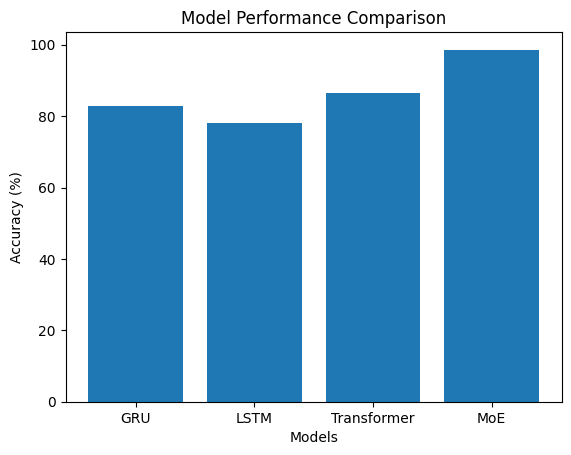

In [ ]:
import matplotlib.pyplot as plt

models = ["GRU", "LSTM", "Transformer", "MoE"]
accuracies = [82.9, 78.0, 86.4, 98.6]

plt.figure()
plt.bar(models, accuracies)
plt.xlabel("Models")
plt.ylabel("Accuracy (%)")
plt.title("Model Performance Comparison")
plt.savefig("accuracy_graph.png")
plt.show()